# 03 — Churn Driver Analysis

**Project:** Cohort & Retention Analysis  
**Business question:** *Why* did customers stop buying?

Phase 2 cleaned the data. Phase 3 showed *when* customers churn (mostly between month 0 and month 1). This notebook digs into *why* — by comparing customers who came back vs. customers who didn't, across three lenses.

## Tooling
We use **DuckDB** to run real SQL directly against the cleaned Parquet file — no separate database to spin up. Each query lives in its own `.sql` file in the `sql/` folder so it can be copy-pasted into Tableau, BigQuery, or any other SQL tool.

## How we define "churn"
Comparing lifetime behaviour is biased: a customer who joined in November 2011 only had one month of follow-up, so calling them "churned" because they never came back is unfair. We control for this with a **90-day retention** rule:

- A customer is **eligible** if their first purchase was ≥ 90 days before the dataset ends.
- An eligible customer is **retained** if they placed at least one more order in the 90 days after their first.
- Otherwise they're **churned**.

All driver comparisons use only the eligible population.

**Outputs**
- `data/clean/churn_drivers_summary.csv` — one row per driver, the headline number
- `data/clean/retention_by_country.csv`
- `data/clean/retention_by_acquisition_month.csv`
- `data/clean/aov_by_outcome.csv`
- `reports/churn_drivers.png` — three-panel summary chart

## 0. Setup — DuckDB + the cleaned data

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_DIR    = PROJECT_ROOT / "data" / "clean"
SQL_DIR      = PROJECT_ROOT / "sql"
REPORTS_DIR  = PROJECT_ROOT / "reports"

def load_sql(name: str) -> str:
    return (SQL_DIR / name).read_text(encoding="utf-8")

# In-memory DuckDB. Register the Parquet file as a SQL view.
con = duckdb.connect()
con.execute(f"""
    CREATE OR REPLACE VIEW transactions AS
    SELECT * FROM read_parquet('{(CLEAN_DIR / "online_retail_clean.parquet").as_posix()}');
""")

con.execute("SELECT COUNT(*) AS rows, MIN(InvoiceDate) AS min_d, MAX(InvoiceDate) AS max_d FROM transactions").df()

,rows,min_d,max_d
0,805549,2009-12-01 07:45:00,2011-12-09 12:50:00


## 1. Build the per-customer fact table

`sql/00_customer_summary.sql` collapses transactions into **one row per customer** with first-purchase date, country, order count, lifetime revenue, and the two key flags `eligible_for_90d` and `retained_90d`. We run it once and inspect the result.

In [2]:
con.execute(load_sql("00_customer_summary.sql"))

customers = con.execute("SELECT * FROM customers").df()
print("customers shape:", customers.shape)
customers.head()

customers shape: (5878, 10)


,CustomerID,first_purchase_date,first_purchase_month,first_country,first_order_value,total_orders,lifetime_revenue,last_purchase_date,eligible_for_90d,retained_90d
0,12682,2009-12-01 09:28:00,2009-12-01,France,426.30,52,24033.91,2011-12-06 10:00:00,True,True
1,16011,2009-12-01 12:02:00,2009-12-01,United Kingdom,192.75,29,5880.46,2011-12-01 16:31:00,True,True
2,18037,2009-12-01 13:48:00,2009-12-01,United Kingdom,21.95,15,167.42,2011-07-08 13:39:00,True,True
3,13381,2009-12-01 15:19:00,2009-12-01,United Kingdom,17.40,12,8224.37,2011-11-08 11:58:00,True,True
4,14865,2009-12-01 16:05:00,2009-12-01,United Kingdom,31.20,4,129.72,2011-12-02 16:25:00,True,False


In [3]:
# Quick sanity check on the population we'll judge
con.execute("""
    SELECT
        COUNT(*)                                                       AS customers_total,
        SUM(CASE WHEN eligible_for_90d THEN 1 ELSE 0 END)              AS eligible_for_90d,
        SUM(CASE WHEN eligible_for_90d AND retained_90d THEN 1 ELSE 0 END) AS retained_90d,
        ROUND(100.0 * SUM(CASE WHEN eligible_for_90d AND retained_90d THEN 1 ELSE 0 END)
                    / NULLIF(SUM(CASE WHEN eligible_for_90d THEN 1 ELSE 0 END), 0), 1) AS overall_retention_90d_pct
    FROM customers
""").df()

,customers_total,eligible_for_90d,retained_90d,overall_retention_90d_pct
0,5878,5281.0,2491.0,47.2


## 2. Driver 1 — One-and-done customers

The simplest churn lens: what share of customers bought exactly once, ever?

(This uses *lifetime* orders, not the 90-day window, because the question is structural — "how big is the one-shot segment?" — not cohort-controlled.)

In [4]:
driver1 = con.execute(load_sql("01_single_order_share.sql")).df()
driver1

,customers_total,one_order_customers,one_order_pct,avg_orders_per_customer,median_orders_per_customer
0,5878,1623.0,27.6,6.29,3.0


## 3. Driver 2 — Geography

Does 90-day retention vary by shipping country? UK accounts for ~90% of customers so it's our baseline.

In [5]:
by_country = con.execute(load_sql("02_retention_by_country.sql")).df()
by_country

,country,customers,retention_90d_pct,avg_first_order_value,avg_lifetime_revenue
0,United Kingdom,4813,46.9,387.10,2986.41
1,Germany,93,60.2,790.60,4553.07
2,France,76,56.6,500.48,4368.64
3,Spain,34,35.3,629.31,3100.29


In [6]:
uk_retention = by_country.loc[by_country["country"] == "United Kingdom", "retention_90d_pct"].iloc[0]
by_country = by_country.assign(vs_uk_pp=(by_country["retention_90d_pct"] - uk_retention).round(1))

print(f"UK baseline 90-day retention: {uk_retention:.1f}%\n")
print("Countries ranked from worst to best (vs UK, in percentage points):")
by_country.sort_values("vs_uk_pp")[["country", "customers", "retention_90d_pct", "vs_uk_pp"]]

UK baseline 90-day retention: 46.9%

Countries ranked from worst to best (vs UK, in percentage points):


,country,customers,retention_90d_pct,vs_uk_pp
3,Spain,34,35.3,-11.6
0,United Kingdom,4813,46.9,0.0
2,France,76,56.6,9.7
1,Germany,93,60.2,13.3


## 4. Driver 3 — Acquisition seasonality

Customers acquired during peak shopping months (Nov/Dec — Christmas) are often **gift buyers** who never become regulars. Let's see if the data agrees.

In [7]:
by_month = con.execute(load_sql("03_retention_by_acquisition_month.sql")).df()
by_month["cohort_month"] = pd.to_datetime(by_month["cohort_month"])
by_month["calendar_month"] = by_month["cohort_month"].dt.month_name()
by_month

,cohort_month,new_customers,retention_90d_pct,avg_first_order_value,calendar_month
0,2009-12-01,955,61.4,420.14,December
1,2010-01-01,383,52.2,383.84,January
2,2010-02-01,374,52.7,397.46,February
3,2010-03-01,443,44.0,443.54,March
4,2010-04-01,294,40.8,403.88,April
5,2010-05-01,254,37.0,403.70,May
6,2010-06-01,270,40.0,437.89,June
7,2010-07-01,186,45.2,322.02,July
8,2010-08-01,162,53.7,334.80,August
9,2010-09-01,243,46.5,606.62,September


In [8]:
# Group by calendar month to flatten the seasonality signal
season = (
    by_month.assign(month_num=by_month["cohort_month"].dt.month)
            .groupby(["month_num", "calendar_month"])
            .agg(cohorts=("cohort_month", "size"),
                 new_customers=("new_customers", "sum"),
                 retention_90d_pct=("retention_90d_pct", "mean"))
            .round(1)
            .reset_index()
            .sort_values("month_num")
)
season

,month_num,calendar_month,cohorts,new_customers,retention_90d_pct
0,1,January,2,454,46.5
1,2,February,2,498,42.5
2,3,March,2,622,43.5
3,4,April,2,400,40.2
4,5,May,2,365,40.6
5,6,June,2,378,45.0
6,7,July,2,288,51.0
7,8,August,2,268,52.8
8,9,September,2,275,57.6
9,10,October,1,377,40.6


## 5. Bonus — First-order value vs. coming back

Are customers who placed bigger first orders more likely to return?

In [9]:
aov = con.execute(load_sql("04_aov_by_outcome.sql")).df()
aov

,outcome,customers,avg_first_order_value,median_first_order_value,avg_lifetime_revenue
0,returned within 90d,2491,485.03,315.66,5646.60
1,churned (no return in 90d),2790,355.27,257.71,1173.06


## 6. Visualize the three drivers

Saved → C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\reports\churn_drivers.png


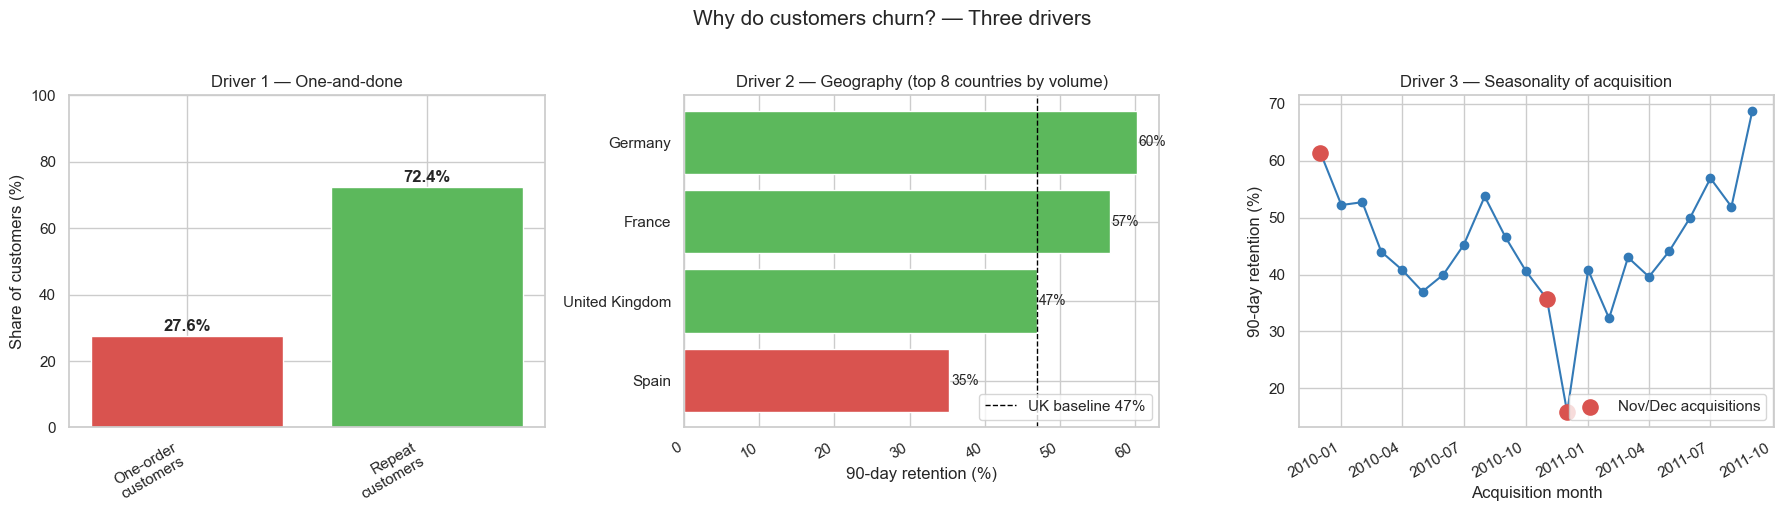

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: one-and-done share ---
ax = axes[0]
one_pct = float(driver1["one_order_pct"].iloc[0])
repeat_pct = 100 - one_pct
ax.bar(["One-order\ncustomers", "Repeat\ncustomers"],
       [one_pct, repeat_pct],
       color=["#d9534f", "#5cb85c"])
for i, v in enumerate([one_pct, repeat_pct]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_ylabel("Share of customers (%)")
ax.set_title("Driver 1 — One-and-done")

# --- Panel 2: retention by country (top 8 by volume) ---
ax = axes[1]
top = by_country.sort_values("customers", ascending=False).head(8).sort_values("retention_90d_pct")
colors = ["#d9534f" if r < uk_retention else "#5cb85c" for r in top["retention_90d_pct"]]
ax.barh(top["country"], top["retention_90d_pct"], color=colors)
ax.axvline(uk_retention, color="black", linestyle="--", linewidth=1, label=f"UK baseline {uk_retention:.0f}%")
for y, v in enumerate(top["retention_90d_pct"]):
    ax.text(v + 0.3, y, f"{v:.0f}%", va="center", fontsize=10)
ax.set_xlabel("90-day retention (%)")
ax.set_title("Driver 2 — Geography (top 8 countries by volume)")
ax.legend(loc="lower right")

# --- Panel 3: retention by acquisition cohort ---
ax = axes[2]
ax.plot(by_month["cohort_month"], by_month["retention_90d_pct"], marker="o", color="#337ab7")
# highlight Nov/Dec acquisitions
holiday = by_month[by_month["cohort_month"].dt.month.isin([11, 12])]
ax.scatter(holiday["cohort_month"], holiday["retention_90d_pct"],
           color="#d9534f", s=120, zorder=5, label="Nov/Dec acquisitions")
ax.set_xlabel("Acquisition month")
ax.set_ylabel("90-day retention (%)")
ax.set_title("Driver 3 — Seasonality of acquisition")
ax.legend(loc="lower right")
fig.autofmt_xdate()

plt.suptitle("Why do customers churn? — Three drivers", fontsize=15, y=1.02)
plt.tight_layout()
out_path = REPORTS_DIR / "churn_drivers.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved →", out_path)
plt.show()

## 7. Findings summary

Pulling the headline numbers from the queries above into a single tidy table — this is what we'll quote in the Tableau dashboard and the README.

In [11]:
# Numbers we want to ship
one_order_pct = float(driver1["one_order_pct"].iloc[0])

uk_row     = by_country.loc[by_country["country"] == "United Kingdom"].iloc[0]
worst_geo  = by_country.sort_values("retention_90d_pct").iloc[0]
best_geo   = by_country.sort_values("retention_90d_pct", ascending=False).iloc[0]

month_avg  = season.set_index("calendar_month")["retention_90d_pct"]
nov_dec    = season[season["month_num"].isin([11, 12])]["retention_90d_pct"].mean()
others_avg = season[~season["month_num"].isin([11, 12])]["retention_90d_pct"].mean()

aov_returned = aov.loc[aov["outcome"] == "returned within 90d"].iloc[0]
aov_churned  = aov.loc[aov["outcome"].str.startswith("churned")].iloc[0]

findings = pd.DataFrame([
    {
        "driver": "Driver 1 — One-and-done customers",
        "headline": f"{one_order_pct:.1f}% of customers bought exactly once and never returned.",
        "detail":  f"Avg orders/customer = {driver1['avg_orders_per_customer'].iloc[0]}, median = {int(driver1['median_orders_per_customer'].iloc[0])}.",
    },
    {
        "driver": "Driver 2 — Geography",
        "headline": (
            f"UK customers retain at {uk_row['retention_90d_pct']:.0f}% over 90 days, "
            f"but {worst_geo['country']} retains at only {worst_geo['retention_90d_pct']:.0f}% "
            f"({(worst_geo['retention_90d_pct'] / uk_row['retention_90d_pct']):.0%} of the UK rate)."
        ),
        "detail": f"Best performer: {best_geo['country']} at {best_geo['retention_90d_pct']:.0f}%.",
    },
    {
        "driver": "Driver 3 — Holiday-season acquisitions",
        "headline": (
            f"Customers acquired in Nov/Dec retain at {nov_dec:.0f}% — "
            f"{(others_avg - nov_dec):.0f} percentage points below the {others_avg:.0f}% average for the rest of the year."
        ),
        "detail": "Consistent with a gift-buying pattern: Christmas customers don't become regulars.",
    },
    {
        "driver": "Bonus — First-order value",
        "headline": (
            f"Customers who returned spent £{aov_returned['avg_first_order_value']:.0f} on their first order; "
            f"churned customers spent £{aov_churned['avg_first_order_value']:.0f}."
        ),
        "detail": f"Median first-order value: £{aov_returned['median_first_order_value']:.0f} (returned) vs £{aov_churned['median_first_order_value']:.0f} (churned).",
    },
])
findings

,driver,headline,detail
0,Driver 1 — One-and-done customers,27.6% of customers bought exactly once and nev...,"Avg orders/customer = 6.29, median = 3."
1,Driver 2 — Geography,"UK customers retain at 47% over 90 days, but S...",Best performer: Germany at 60%.
2,Driver 3 — Holiday-season acquisitions,Customers acquired in Nov/Dec retain at 37% — ...,Consistent with a gift-buying pattern: Christm...
3,Bonus — First-order value,Customers who returned spent £485 on their fir...,Median first-order value: £316 (returned) vs £...


## 8. Save outputs for Tableau

In [12]:
findings.to_csv(CLEAN_DIR / "churn_drivers_summary.csv", index=False)
by_country.to_csv(CLEAN_DIR / "retention_by_country.csv", index=False)
by_month.to_csv(CLEAN_DIR / "retention_by_acquisition_month.csv", index=False)
aov.to_csv(CLEAN_DIR / "aov_by_outcome.csv", index=False)

print("Saved CSVs:")
for name in ["churn_drivers_summary.csv", "retention_by_country.csv", "retention_by_acquisition_month.csv", "aov_by_outcome.csv"]:
    p = CLEAN_DIR / name
    print(f"  {p}  ({p.stat().st_size/1024:.1f} KB)")

Saved CSVs:
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\churn_drivers_summary.csv  (0.7 KB)
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\retention_by_country.csv  (0.2 KB)
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\retention_by_acquisition_month.csv  (0.8 KB)
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\aov_by_outcome.csv  (0.2 KB)


## Next: Phase 5 — Tableau dashboard

The CSVs in `data/clean/` are the four inputs for the Tableau workbook:

1. `cohort_retention_long.csv` → cohort heatmap
2. `retention_by_country.csv` → bar chart, UK vs world
3. `retention_by_acquisition_month.csv` → line chart with Nov/Dec highlighted
4. `churn_drivers_summary.csv` → text callouts (KPI cards)